In [1]:
pip install openpyxl streamlit

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.2 MB 1.5 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.2 MB 1.5 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/9.2 MB 1.5 MB/s eta 0:00:06
   ------ --------------------------------- 1.6/9.2 MB 1.4 MB/s eta 0:00:06
   --------- ------------------------------ 2.1/9.2 MB 1.5 MB/s eta 0:00:05
   ---------- ----------------------------- 2.4/9.2 MB 1.5 MB/s eta 0:00:05
   ----------- ---------------------------- 2.6/9.2 MB 1.5 MB/s eta 0:00:05
   ------------- -------------------------- 3.1/9.2 MB 1.5 MB/s eta 0:00:04
   -------------- ------------------------- 3.4/9.2 MB 1.6 MB/s eta 0:00:04
   --------------- ------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd

In [52]:
df = pd.read_csv('HHS_Unaccompanied_Alien_Children_Program.csv')

In [53]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 55.0+ KB


In [55]:
df.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,173.406944
std,72.646625,126.354965,97.322012,125.702841
min,0.000000,7.000000,0.000000,0.000000
25%,12.000000,36.000000,14.000000,19.750000
50%,99.000000,193.000000,157.000000,181.000000
75%,147.250000,263.250000,199.250000,267.000000
max,333.000000,531.000000,440.000000,505.000000


In [56]:
df.isnull().sum()

Date                                               450
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64

In [57]:
df.shape

(1170, 6)

In [58]:
df['Date'] = pd.to_datetime(df['Date'])

In [59]:
df.dropna()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2025-12-21,6.0,18.0,11.0,"2,484",14.0
1,2025-12-18,11.0,50.0,6.0,"2,472",16.0
2,2025-12-17,7.0,31.0,11.0,"2,481",10.0
3,2025-12-16,8.0,54.0,15.0,"2,468",9.0
4,2025-12-15,11.0,42.0,9.0,"2,470",7.0
...,...,...,...,...,...,...
715,2023-01-25,20.0,22.0,41.0,"7,538",180.0
716,2023-01-24,47.0,42.0,47.0,"7,433",175.0
717,2023-01-23,32.0,50.0,39.0,"7,280",181.0
718,2023-01-22,32.0,49.0,39.0,"7,122",227.0


In [60]:
df.drop_duplicates(inplace=True)

In [61]:
df.shape

(721, 6)

In [62]:
df.columns = [
    'Date',
    'Apprehended',
    'CBP_Custody',
    'Transferred_Out',
    'HHS_Care',
    'Discharged'
]

In [63]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Day_name'] = df['Date'].dt.day_name()

In [64]:
# KPI 1
# Transfer efficiency
df['Transfer_Efficiency'] = df['Transferred_Out'] / df['CBP_Custody']

In [66]:
df.dtypes

Date                   datetime64[ns]
Apprehended                   float64
CBP_Custody                   float64
Transferred_Out               float64
HHS_Care                       object
Discharged                    float64
Month                         float64
Year                          float64
Day_name                       object
Transfer_Efficiency           float64
dtype: object

In [67]:
df['HHS_Care'].head(20)

0     2,484
1     2,472
2     2,481
3     2,468
4     2,470
5     2,462
6     2,437
7     2,439
8     2,443
9     2,440
10    2,429
11    2,418
12    2,419
13    2,407
14    2,410
15    2,415
16    2,389
17    2,375
18    2,371
19    2,375
Name: HHS_Care, dtype: object

In [68]:
df['HHS_Care'] = (
    df['HHS_Care']
    .astype(str)
    .str.replace(',', '')
    .str.strip()
)

df['HHS_Care'] = pd.to_numeric(
    df['HHS_Care'],
    errors='coerce'
)

df['HHS_Care'] = (
    df['HHS_Care']
    .fillna(0)
    .astype(int)
)

In [69]:
df["HHS_Care"].head(20)

0     2484
1     2472
2     2481
3     2468
4     2470
5     2462
6     2437
7     2439
8     2443
9     2440
10    2429
11    2418
12    2419
13    2407
14    2410
15    2415
16    2389
17    2375
18    2371
19    2375
Name: HHS_Care, dtype: int64

In [81]:
df.isnull().sum()

Date                       1
Apprehended                1
CBP_Custody                1
Transferred_Out            1
HHS_Care                   0
Discharged                 1
Month                      1
Year                       1
Day_name                   1
Transfer_Efficiency        1
Dischared_Effectiveness    1
Pipeline_Throughput        1
Backlog_Accumulation       1
dtype: int64

In [83]:
import numpy as np
np.isinf(df.select_dtypes(include=np.number)).sum()

Apprehended                0
CBP_Custody                0
Transferred_Out            0
HHS_Care                   0
Discharged                 0
Month                      0
Year                       0
Transfer_Efficiency        0
Dischared_Effectiveness    0
Pipeline_Throughput        2
Backlog_Accumulation       0
dtype: int64

In [84]:
df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

In [85]:
np.isinf(df.select_dtypes(include=np.number)).sum()

Apprehended                0
CBP_Custody                0
Transferred_Out            0
HHS_Care                   0
Discharged                 0
Month                      0
Year                       0
Transfer_Efficiency        0
Dischared_Effectiveness    0
Pipeline_Throughput        0
Backlog_Accumulation       0
dtype: int64

In [70]:
# KPI 2
# Dischare effectiveness
df['Dischared_Effectiveness'] = df['Discharged'] / df['HHS_Care']

In [71]:
# KPI 3
# Pipeline throughput
df['Pipeline_Throughput'] = df['Discharged'] / df['Apprehended']

In [72]:
# KPI 4
# Backlog accumulation
df['Backlog_Accumulation'] = df['Apprehended'] - df['Discharged']

In [73]:
import matplotlib.pyplot as plt

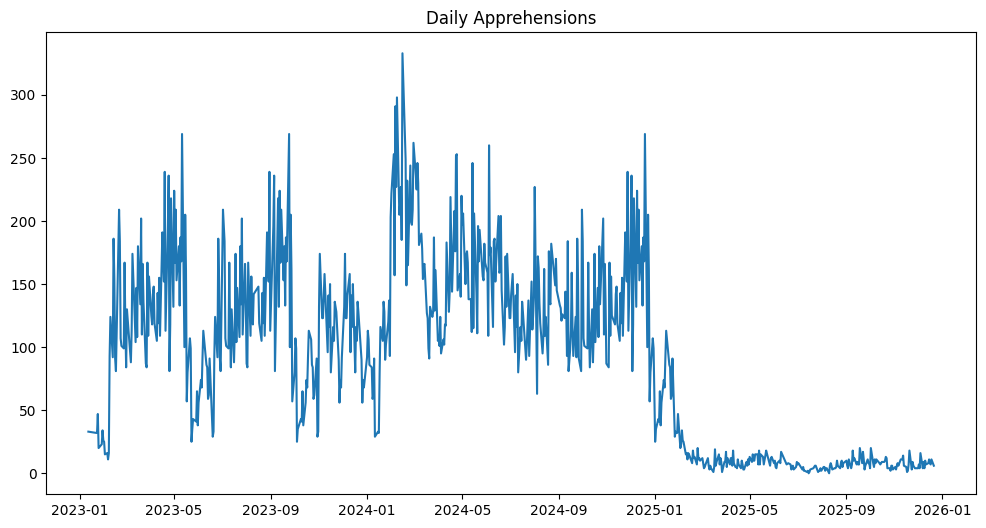

In [74]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Apprehended'])
plt.title('Daily Apprehensions')
plt.show()

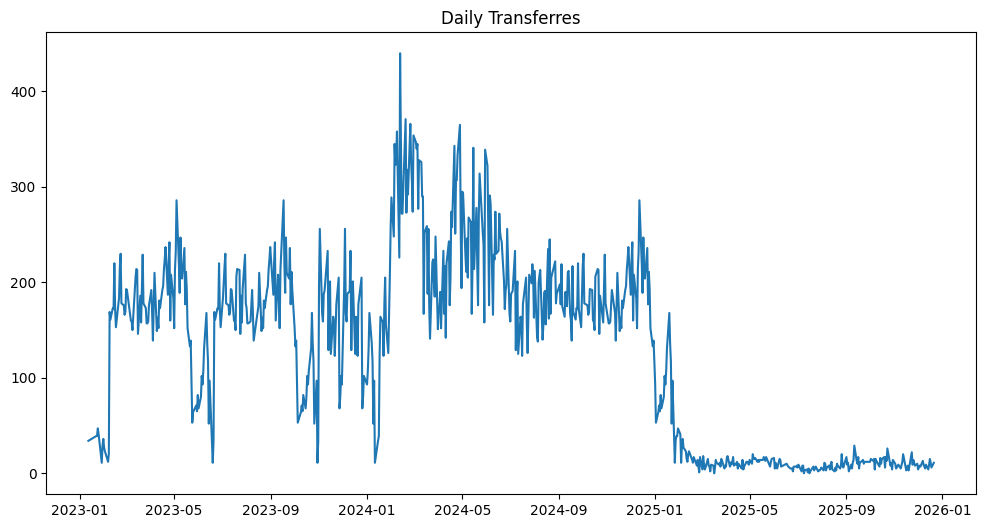

In [75]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Transferred_Out'])
plt.title('Daily Transferres')
plt.show()

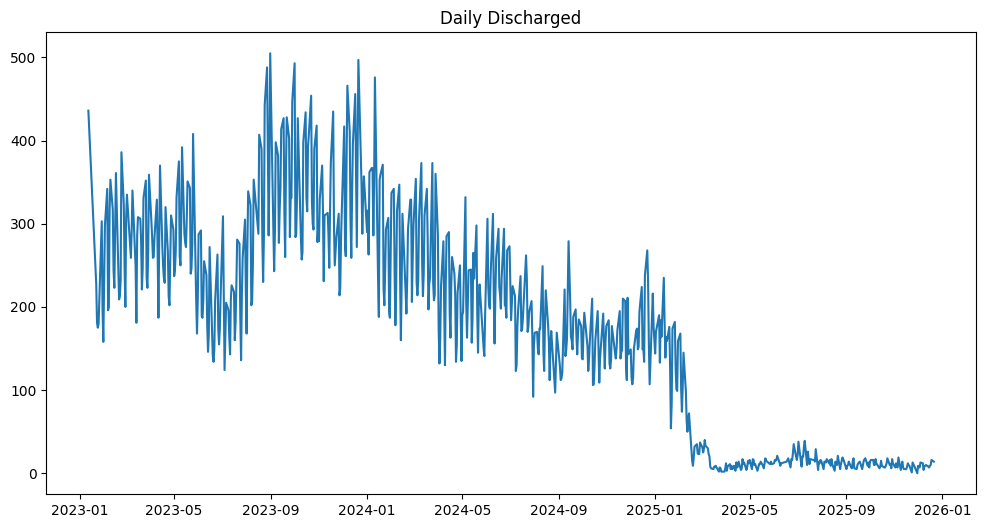

In [76]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Discharged'])
plt.title('Daily Discharged')
plt.show()

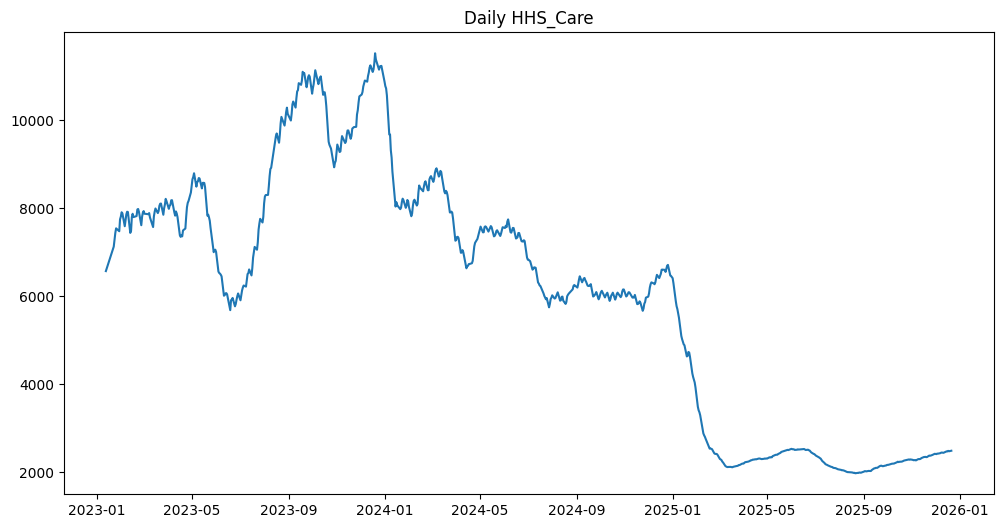

In [77]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['HHS_Care'])
plt.title('Daily HHS_Care')
plt.show()

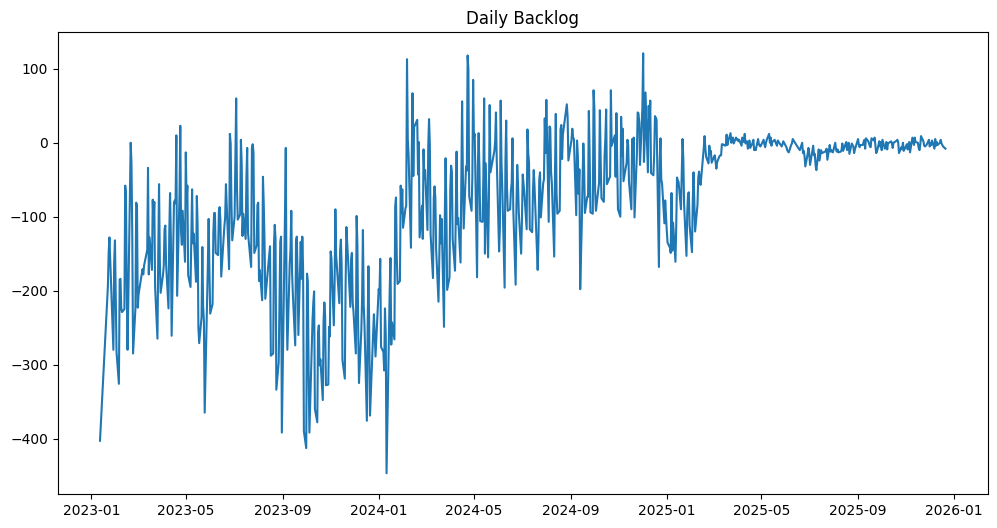

In [78]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Backlog_Accumulation'])
plt.title('Daily Backlog')
plt.show()

In [79]:
import seaborn as sns

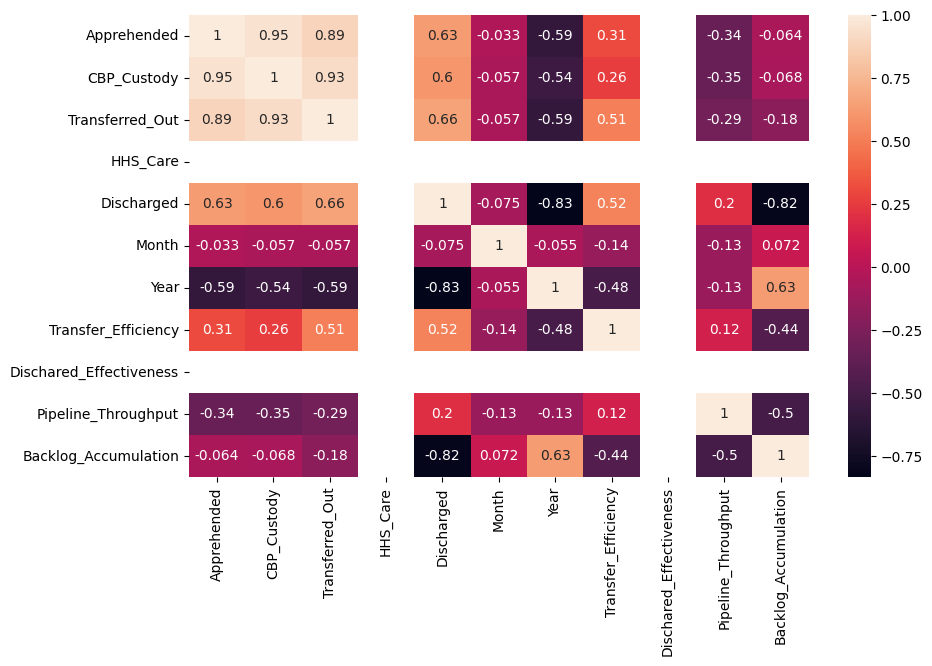

In [45]:
corr = df.corr(numeric_only = True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.show()

In [48]:
df['Stability_Score'] = df['Dischared_Effectiveness'].rolling(7).std()

In [89]:
df.to_csv(
    "cleaned_data.csv",
    index=False
)